# Inside Wind Speed & Turbulence vs Relative Wind Pointing

Compares wind speed and turbulence from ESS Gill anemometers mounted on the TMA
against the **relative wind pointing** — the angle between incoming wind direction
and dome azimuth position.

**Inside turbulence sensors (`lsst.sal.ESS.airTurbulence`, field `speedMagnitude`):**

| salIndex | Location |
|---|---|
| 110 | TMA deployable platform |
| 123 | TMA top ring −X/−Y |
| 124 | TMA top ring +X/−Y |
| 125 | TMA top ring +X/+Y |
| 126 | TMA top ring −X/+Y |

**Wind direction:** `lsst.sal.ESS.airFlow` index 301 (calibration hill weather station) → `direction` (deg)  
**Dome azimuth:** `lsst.sal.MTDome.azimuth` → `positionActual` (deg)  
**Relative wind pointing:** `wind_direction − dome_azimuth`, wrapped to [−180, 180] deg

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

%matplotlib inline

In [13]:
client = EfdClient("usdf_efd")
print("Connected to EFD")

Connected to EFD


## Inspect Schemas

Confirm field names for the airTurbulence and airFlow topics.

In [14]:
turb_topic = "lsst.sal.ESS.airTurbulence"
flow_topic = "lsst.sal.ESS.airFlow"

print("=== airTurbulence ===")
_orig_get_schema = client.get_schema

async def _safe_get_schema(topic):
    try:
        return await _orig_get_schema(topic)
    except Exception as e:
        return {
            "topic": topic,
            "warning": "Schema registry unavailable; proceeding with configured field names.",
            "error": f"{type(e).__name__}: {e}",
        }

client.get_schema = _safe_get_schema
display(await client.get_schema(turb_topic))
print("=== airFlow ===")
display(await client.get_schema(flow_topic))

=== airTurbulence ===


{'topic': 'lsst.sal.ESS.airTurbulence',
 'warning': 'Schema registry unavailable; proceeding with configured field names.',
 'error': 'ClientConnectorDNSError: Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]'}

=== airFlow ===


{'topic': 'lsst.sal.ESS.airFlow',
 'warning': 'Schema registry unavailable; proceeding with configured field names.',
 'error': 'ClientConnectorDNSError: Cannot connect to host sasquatch-schema-registry.sasquatch:8081 ssl:default [Name or service not known]'}

## Configuration

Set the time range and field names here.  Adjust `speed_field` and `direction_field`
if the schema above shows different names.

In [15]:
t_end   = Time("2026-03-15T05:00:00", scale="utc")
t_start = t_end - TimeDelta(10*u.week)

print(f"Start : {t_start.iso}")
print(f"End   : {t_end.iso}")

# Field names — adjust if schema above differs
speed_field     = "speedMagnitude"          # scalar wind speed from airTurbulence (m/s)
sonic_field     = "sonicTemperatureStdDev"  # sonic temp std dev — proxy for thermal turbulence (deg_C)
direction_field = "direction"               # wind direction from airFlow weather station (deg)

# Inside turbulence sensors: index → label
ess_sensors = {
    110: "TMA Platform",
    123: "Top Ring −X/−Y",
    124: "Top Ring +X/−Y",
    125: "Top Ring +X/+Y",
    126: "Top Ring −X/+Y",
}

# Sensors to average for the "Top Ring Mean" subplot (included whenever ≥2 are active)
top_ring_indices = [123, 124, 125, 126]

# Wind direction source
weather_index = 301

# Aperture shutter filter — both doors must exceed this to be included (percent open)
shutter_threshold = 95.0

# Outside wind speed discrimination bins (m/s) — used to color/split all scatter and binned plots
wind_speed_bins   = [0, 3, 6, 9, 12, np.inf]
wind_speed_labels = ["0–3 m/s", "3–6 m/s", "6–9 m/s", "9–12 m/s", ">12 m/s"]
wind_speed_colors = ["steelblue", "mediumseagreen", "goldenrod", "tomato", "mediumpurple"]

# Per-sensor speed clip thresholds (m/s) — rows at or above this value are excluded as bad data.
# Set to None to apply no filter for that sensor.
# Review the diagnostic cell output below to tune these values.
speed_clip = {
    110: None,    # distribution looks clean; max = 7.019 m/s (N=1)
    123: 8.6,    # fill-value spike at ~52 m/s
    124: 8.6,    # fill-value spike at ~52 m/s
    125: 8.6,   # hard clip at exactly 8.655 m/s (N≈85k identical values)
    126: 8.6,    # review diagnostic output to decide threshold
}

# ── Parquet cache ────────────────────────────────────────────────────
CACHE_FILE           = "ess_wind_dome_joined.parquet"
FORCE_REFETCH        = False   # True → ignore cache, re-fetch everything
INCREMENTAL_REFETCH  = False   # True → extend cache with newer data


Start : 2026-01-04 05:00:00.000
End   : 2026-03-15 05:00:00.000


In [ ]:
import pathlib as _pl
_cp = _pl.Path(CACHE_FILE)
_from_cache = False
if not FORCE_REFETCH and _cp.exists():
    df_all = pd.read_parquet(_cp)
    _from_cache = True
    print(f"✓ Loaded {len(df_all):,} rows from cache: {_cp}")
elif FORCE_REFETCH:
    print("FORCE_REFETCH=True — bypassing cache")
else:
    print(f"No cache at {_cp} — will fetch fresh data")

## Fetch Data

In [16]:
if not _from_cache:
    # Fetch ESS airTurbulence (inside wind speed + sonic temp std dev) for each sensor
    ess_data = {}
    for idx, label in ess_sensors.items():
        df = await client.select_time_series(
            turb_topic,
            fields=[speed_field, sonic_field],
            start=t_start,
            end=t_end,
            index=idx,
        )
        ess_data[idx] = df
        print(f"  [{idx}] {label:20s}  rows={len(df)}")
        df.head()

  [110] TMA Platform          rows=1182672
  [123] Top Ring −X/−Y        rows=741336
  [124] Top Ring +X/−Y        rows=742032
  [125] Top Ring +X/+Y        rows=742679
  [126] Top Ring −X/+Y        rows=742685


[110] TMA Platform   N=1,182,672  max=7.019 m/s  configured clip: None
     Value (m/s)      Count    x above local baseline
            0.40     20,714                         8x

[123] Top Ring −X/−Y   N=741,336  max=52.110 m/s  configured clip: 8.6
     Value (m/s)      Count    x above local baseline
            8.65     19,593                     19593x
            8.66     58,884                     58884x
            8.67      5,744                      5744x

[124] Top Ring +X/−Y   N=742,032  max=52.156 m/s  configured clip: 8.6
     Value (m/s)      Count    x above local baseline
            8.65      2,707                       902x
            8.66     23,230                      7743x
            8.67     58,137                     19379x
           51.98        387                        11x
           51.99        403                        11x
           52.00        330                         9x

[125] Top Ring +X/+Y   N=742,679  max=8.655 m/s  configured clip: 8.6
  

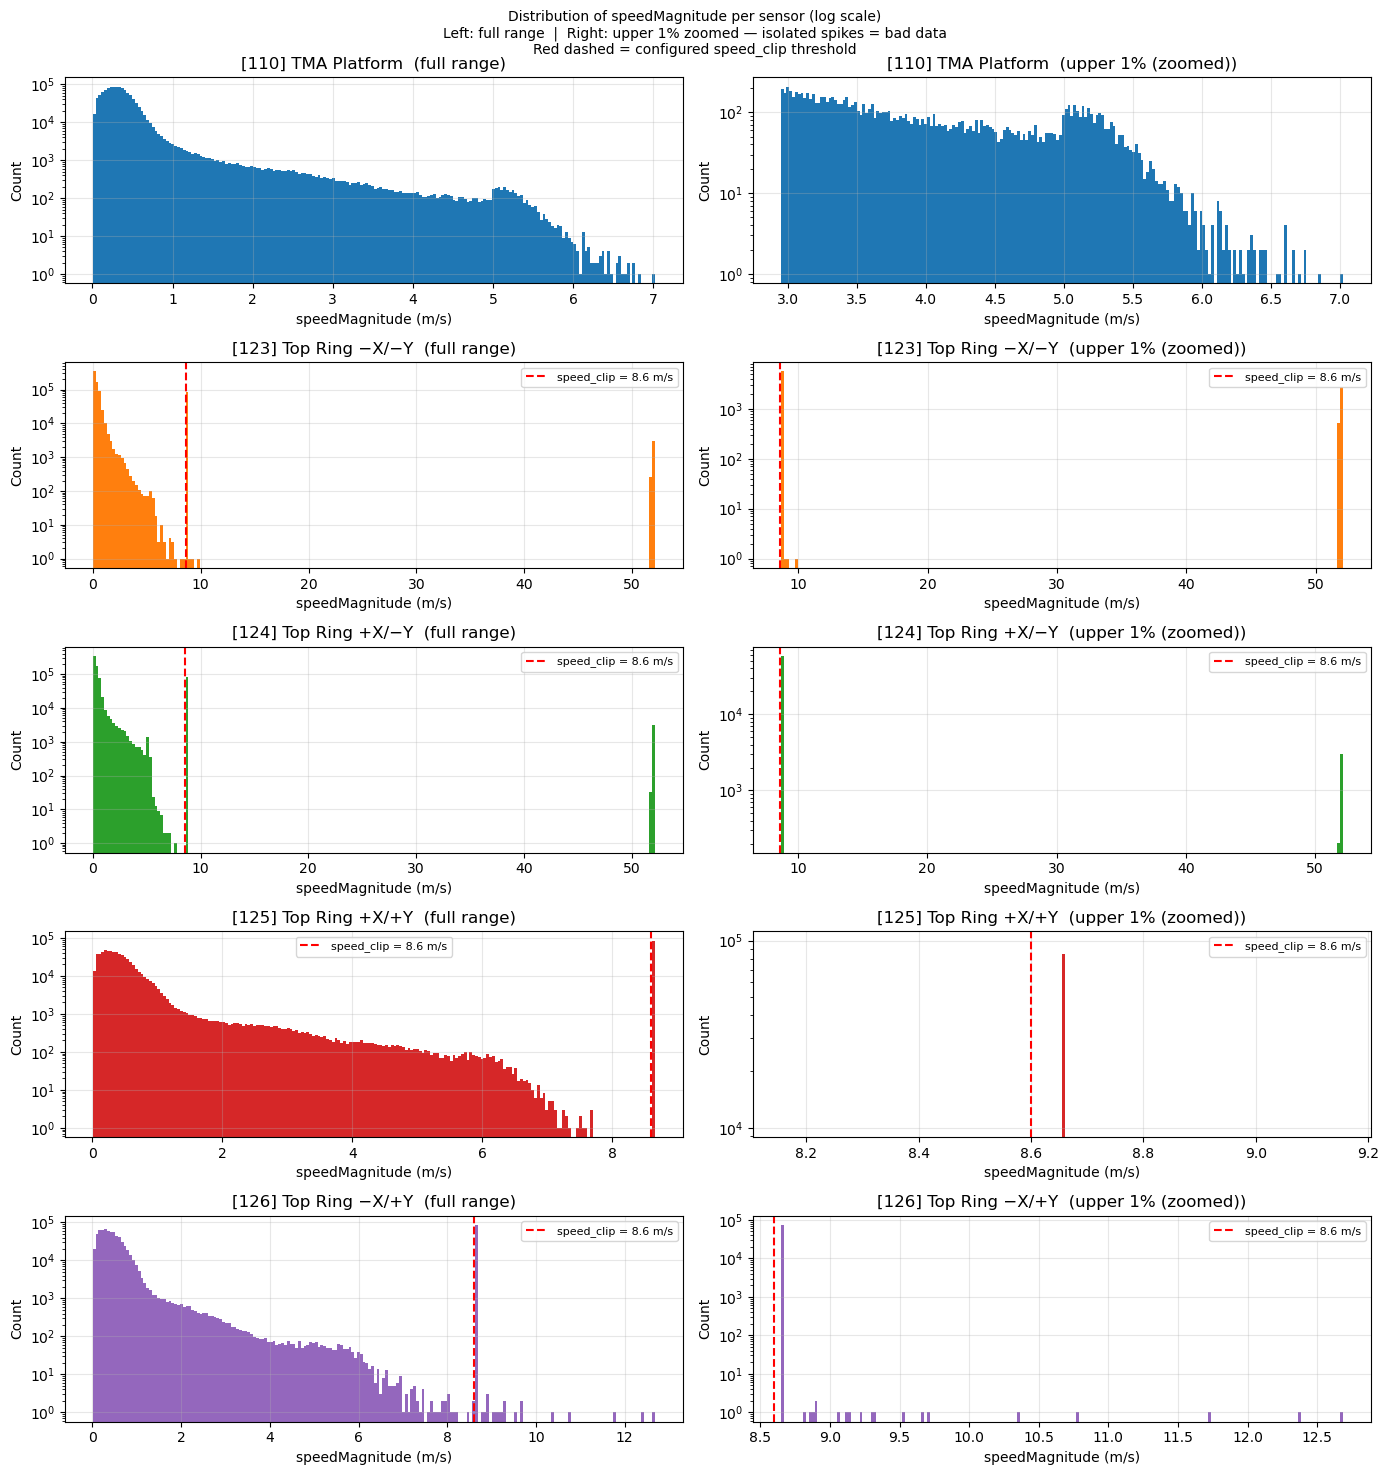

In [17]:
# Identify clipped / saturated values in airTurbulence data per sensor.
# Method: for each rounded value, compare its count to the median count of all
# values within ±1 m/s. A large ratio (spike >> neighbors) = hard clip or fill value.

for idx, label in ess_sensors.items():
    df = ess_data[idx]
    if df.empty:
        print(f"[{idx}] {label}: no data\n")
        continue

    v   = df[speed_field].dropna()
    v_r = v.round(2)
    vc  = v_r.value_counts()

    suspicious = []
    for val, cnt in vc.items():
        neighbors = vc[(vc.index >= val - 1.0) & (vc.index <= val + 1.0) & (vc.index != val)]
        baseline  = max(neighbors.median() if len(neighbors) > 0 else 1.0, 1.0)
        ratio = cnt / baseline
        if ratio > 8 and cnt > 20:
            suspicious.append((val, cnt, ratio))
    suspicious.sort(key=lambda x: x[0])

    thresh = speed_clip.get(idx)
    print(f"[{idx}] {label}   N={len(v):,}  max={v.max():.3f} m/s  configured clip: {thresh}")
    if suspicious:
        print(f"  {'Value (m/s)':>14}  {'Count':>9}  {'x above local baseline':>24}")
        for val, cnt, ratio in suspicious:
            print(f"  {val:>14.2f}  {cnt:>9,}  {ratio:>24.0f}x")
    else:
        print("  No suspicious spikes detected.")
    print()

# Two panels per sensor: full range (left) and upper 1% zoomed (right)
n_sens = len(ess_sensors)
fig, axes = plt.subplots(n_sens, 2, figsize=(14, 3 * n_sens), squeeze=False)

for row_idx, (idx, label) in enumerate(ess_sensors.items()):
    df = ess_data[idx]
    v  = df[speed_field].dropna() if not df.empty else pd.Series(dtype=float)

    for col, (v_plot, title_suffix) in enumerate([
        (v,                             "full range"),
        (v[v >= v.quantile(0.99)],      "upper 1% (zoomed)"),
    ]):
        ax = axes[row_idx, col]
        if v_plot.empty:
            ax.set_visible(False)
            continue

        ax.hist(v_plot, bins=200, color=plt.cm.tab10.colors[row_idx], edgecolor="none")
        ax.set_yscale("log")

        thresh = speed_clip.get(idx)
        if thresh is not None:
            ax.axvline(thresh, color="red", lw=1.5, ls="--", label=f"speed_clip = {thresh} m/s")
            ax.legend(fontsize=8)

        ax.set_xlabel(f"{speed_field} (m/s)")
        ax.set_ylabel("Count")
        ax.set_title(f"[{idx}] {label}  ({title_suffix})")
        ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Distribution of {speed_field} per sensor (log scale)\n"
    "Left: full range  |  Right: upper 1% zoomed — isolated spikes = bad data\n"
    "Red dashed = configured speed_clip threshold",
    fontsize=10,
)
plt.tight_layout()
plt.show()

In [18]:
if not _from_cache:
    # Fetch wind direction and speed from weather station (ESS:301 airFlow)
    df_weather = await client.select_time_series(
        flow_topic,
        fields=[direction_field, "speed"],
        start=t_start,
        end=t_end,
        index=weather_index,
    )
    print(f"Weather station (ESS:{weather_index}) rows: {len(df_weather)}  cols: {list(df_weather.columns)}")
    

Weather station (ESS:301) rows: 4675451  cols: ['direction', 'speed']


In [19]:
if not _from_cache:
    # Fetch MTDome azimuth position
    dome_topic = "lsst.sal.MTDome.azimuth"
    df_dome = await client.select_time_series(
        dome_topic,
        fields="positionActual",
        start=t_start,
        end=t_end,
    )
    print(f"Dome azimuth rows: {len(df_dome)}")
    
    

Dome azimuth rows: 10160814


In [20]:
if not _from_cache:
    # Fetch MTDome aperture shutter position
    # positionActual is a 2-element array (left door, right door) stored as
    # positionActual0 and positionActual1 in the EFD (percent open, 0–100)
    shutter_topic = "lsst.sal.MTDome.apertureShutter"
    df_shutter = await client.select_time_series(
        shutter_topic,
        fields=["positionActual0", "positionActual1"],
        start=t_start,
        end=t_end,
    )
    print(f"Aperture shutter rows: {len(df_shutter)}")
    df_shutter.head()

Aperture shutter rows: 3992780


,positionActual0,positionActual1
2026-01-04 05:00:01.020764+00:00,100.029999,100.010002
2026-01-04 05:00:02.382498+00:00,100.029999,100.010002
2026-01-04 05:00:03.649575+00:00,100.029999,100.010002
2026-01-04 05:00:05.109426+00:00,100.029999,100.010002
2026-01-04 05:00:06.249842+00:00,100.029999,100.010002


## Compute Relative Wind Pointing

1. Interpolate dome azimuth onto the weather station's timestamps.
2. Compute `relative_wind = wind_direction − dome_azimuth` (wrapped to [−180, 180] deg) at each weather station sample.
3. Resample each turbulence sensor to 1 s bins (mean), then align to weather station timestamps via `merge_asof`.

In [21]:
def wrap_angle(angle_deg):
    """Wrap angle to [−180, 180] degrees."""
    return ((angle_deg + 180.0) % 360.0) - 180.0



if not _from_cache:
    # Step 1: interpolate dome azimuth and shutter positions onto weather station timestamps
    ws_t   = df_weather.index.astype(np.int64) / 1e9
    dome_t = df_dome.index.astype(np.int64) / 1e9
    dome_az_at_ws = np.interp(ws_t, dome_t, df_dome["positionActual"].values)
    
    shutter_t   = df_shutter.index.astype(np.int64) / 1e9
    left_at_ws  = np.interp(ws_t, shutter_t, df_shutter["positionActual0"].values)
    right_at_ws = np.interp(ws_t, shutter_t, df_shutter["positionActual1"].values)
    shutter_open = (left_at_ws > shutter_threshold) & (right_at_ws > shutter_threshold)
    
    print(f"Weather station samples with shutter open: {shutter_open.sum()} / {len(shutter_open)}")
    
    # Step 2: build reference DataFrame at weather station timestamps, shutter-open only
    df_ref = df_weather[[direction_field, "speed"]].copy()
    df_ref["dome_az"]       = dome_az_at_ws
    df_ref["relative_wind"] = wrap_angle(df_ref[direction_field] - dome_az_at_ws)
    df_ref = df_ref[shutter_open]
    
    df_ref["speed_bin"] = pd.cut(
        df_ref["speed"],
        bins=wind_speed_bins,
        labels=wind_speed_labels,
        right=False,
    )
    print("Outside wind speed distribution (shutter-open):")
    print(df_ref["speed_bin"].value_counts().sort_index())
    
    df_ref.index.name = "time"
    df_ref_reset = df_ref.reset_index()
    
    # Step 3: for each turbulence sensor, apply clip filter, resample to 1 s bins, then merge_asof
    combined = []
    
    for idx, label in ess_sensors.items():
        df = ess_data[idx].copy()
        if df.empty:
            print(f"  [{idx}] {label}: no data — skipping")
            continue
    
        threshold = speed_clip.get(idx)
        if threshold is not None:
            n_before = len(df)
            df = df[df[speed_field] < threshold]
            print(f"  [{idx}] {label}: clipped {n_before - len(df):,} rows >= {threshold} m/s "
                  f"({100*(n_before - len(df))/n_before:.2f}%)")
    
        df.index.name = "time"
        df_1s = df[[speed_field, sonic_field]].resample("1s").mean().reset_index()
    
        merged = pd.merge_asof(
            df_ref_reset.sort_values("time"),
            df_1s.sort_values("time"),
            on="time",
            direction="nearest",
            tolerance=pd.Timedelta("5s"),
        ).set_index("time")
    
        merged["sensor_idx"] = idx
        merged["label"]      = label
        combined.append(merged)
    
        n_speed = merged[speed_field].notna().sum()
        n_sonic = merged[sonic_field].notna().sum()
        print(f"  [{idx}] {label:20s}  speed matched={n_speed}  sonic matched={n_sonic}")
    
    df_all = pd.concat(combined)
    
    # Step 4: compute mean of active top ring sensors and append as a virtual sensor (idx = -1)
    top_ring_active = [i for i in top_ring_indices if i in ess_sensors and not ess_data[i].empty]
    if len(top_ring_active) > 1:
        ref_cols = [c for c in [direction_field, "speed", "dome_az", "relative_wind", "speed_bin"]
                    if c in df_all.columns]
        tr_rows = df_all[df_all["sensor_idx"].isin(top_ring_active)]
        mean_df = pd.concat([
            tr_rows.groupby(level="time")[[speed_field, sonic_field]].mean(),
            tr_rows.groupby(level="time")[ref_cols].first(),
        ], axis=1)
        mean_df["sensor_idx"] = -1
        mean_df["label"]      = "Top Ring Mean"
        df_all = pd.concat([df_all, mean_df])
        print(f"  [-1] Top Ring Mean ({len(top_ring_active)} sensors)  N={len(mean_df)}")
    

# Shared plot helpers — defined here so all plot cells work independently
sensor_list     = list(ess_sensors.items())
if (df_all["sensor_idx"] == -1).any():
    sensor_list = sensor_list + [(-1, "Top Ring Mean")]

colors          = plt.cm.tab10.colors
bin_edges       = np.arange(-180, 181, 15)
bin_centers     = 0.5 * (bin_edges[:-1] + bin_edges[1:])
bin_centers_rad = np.deg2rad(bin_centers)
bin_edges_rad   = np.deg2rad(bin_edges)
bin_width_rad   = np.deg2rad(15)

Weather station samples with shutter open: 1239422 / 4675451
Outside wind speed distribution (shutter-open):
speed_bin
0–3 m/s     702271
3–6 m/s     412024
6–9 m/s     111799
9–12 m/s     12821
>12 m/s        507
Name: count, dtype: int64
  [110] TMA Platform          speed matched=247670  sonic matched=247670
  [123] Top Ring −X/−Y: clipped 87,411 rows >= 8.6 m/s (11.79%)
  [123] Top Ring −X/−Y        speed matched=169011  sonic matched=169011
  [124] Top Ring +X/−Y: clipped 87,264 rows >= 8.6 m/s (11.76%)
  [124] Top Ring +X/−Y        speed matched=168963  sonic matched=168963
  [125] Top Ring +X/+Y: clipped 85,156 rows >= 8.6 m/s (11.47%)
  [125] Top Ring +X/+Y        speed matched=173741  sonic matched=173741
  [126] Top Ring −X/+Y: clipped 85,181 rows >= 8.6 m/s (11.47%)
  [126] Top Ring −X/+Y        speed matched=173744  sonic matched=173744
  [-1] Top Ring Mean (4 sensors)  N=1239422


In [ ]:
# ── Save / update parquet cache ────────────────────────────────────────
import pathlib as _pl
_cp = _pl.Path(CACHE_FILE)
if _from_cache:
    print("Loaded from cache — skipping save")
elif INCREMENTAL_REFETCH and _cp.exists():
    _old = pd.read_parquet(_cp)
    _combined = pd.concat([_old, df_all]).sort_index()
    _combined = _combined[~_combined.index.duplicated(keep="last")]
    _combined.to_parquet(_cp)
    print(f"✓ Appended incremental data → {len(_combined):,} rows total: {_cp}")
else:
    df_all.to_parquet(_cp)
    print(f"✓ Saved {len(df_all):,} rows → {_cp}")

## Time Series Overview

/lscratch/stalder/tmp/ipykernel_1075117/2428565392.py:55: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/sdf/group/rubin/sw/conda/envs/lsst-scipipe-12.1.0/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


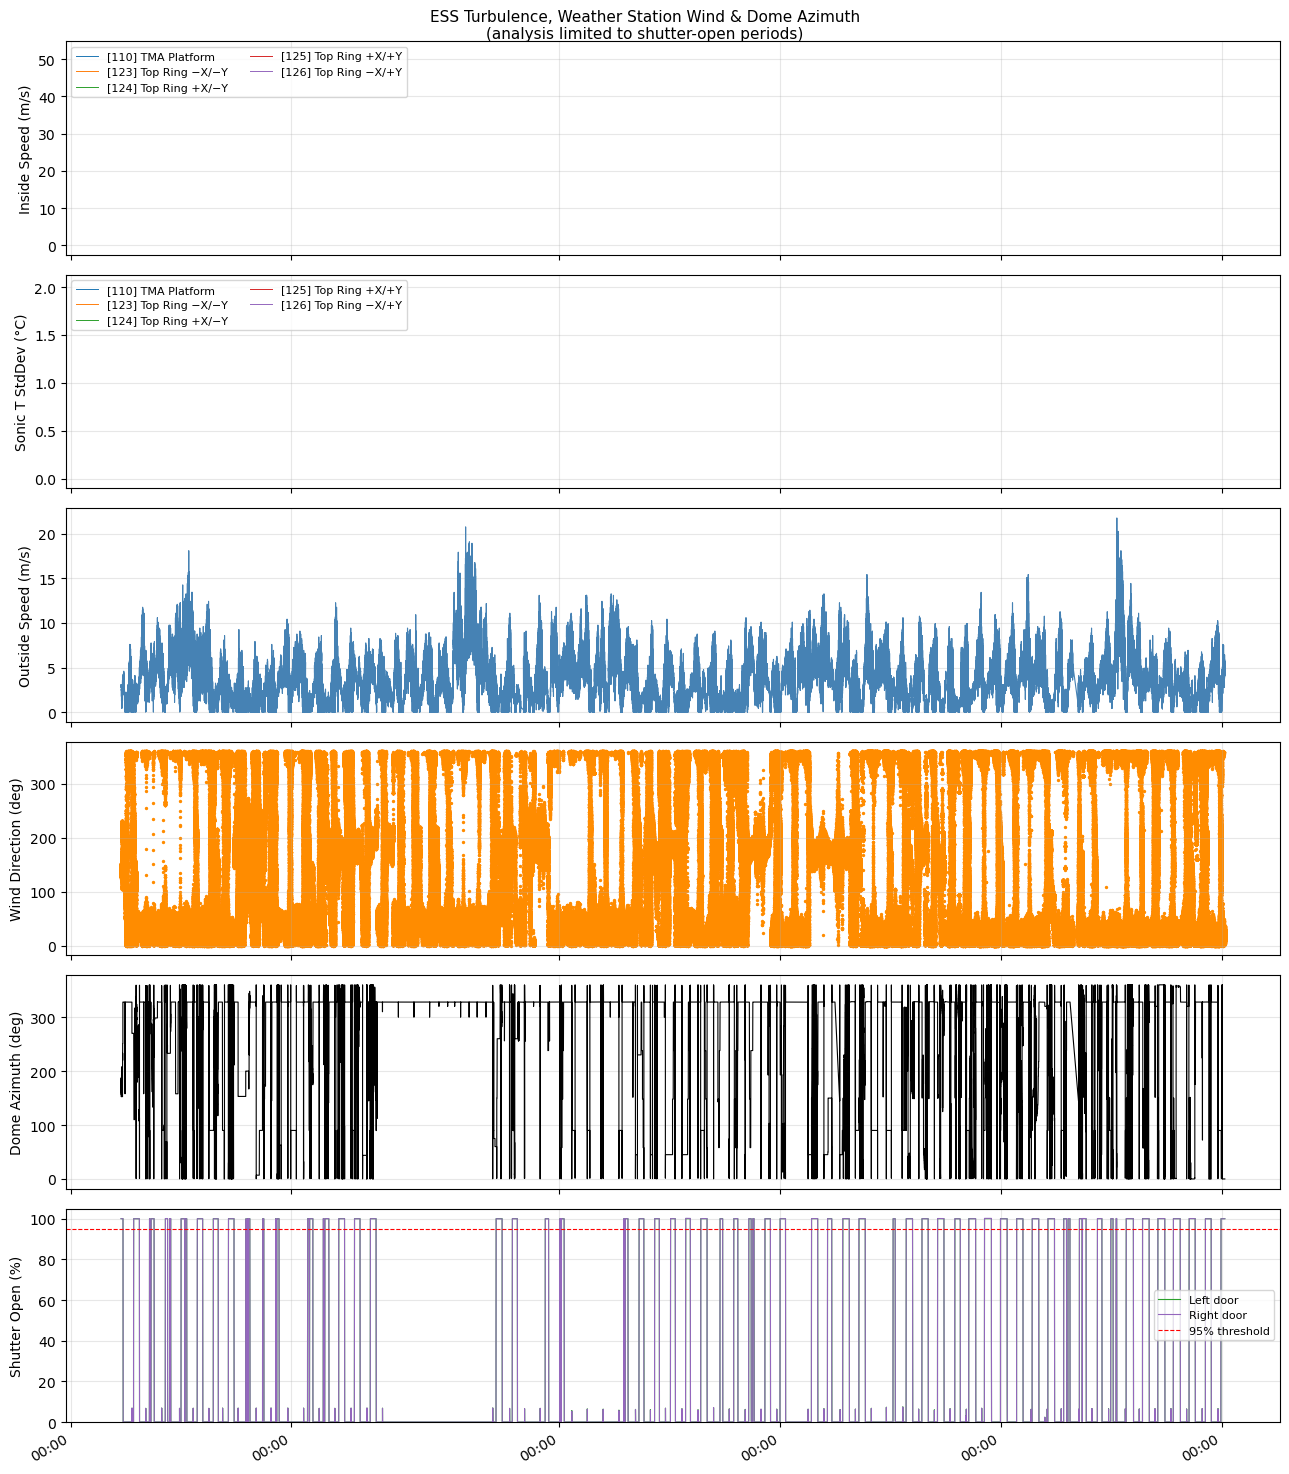

In [22]:
if not _from_cache:
    fig, axes = plt.subplots(6, 1, figsize=(13, 15), sharex=True)
    
    # Row 0: inside wind speed (turbulence sensors, 1 s resampled)
    for i, (idx, label) in enumerate(sensor_list):
        if idx not in ess_data:
            continue
        df = ess_data[idx]
        if df.empty:
            continue
        df_1s = df[[speed_field]].resample("1s").mean()
        axes[0].plot(df_1s.index, df_1s[speed_field], lw=0.7, color=colors[i], label=f"[{idx}] {label}")
    
    # Row 1: sonic temperature std dev (thermal turbulence proxy, 1 s resampled)
    for i, (idx, label) in enumerate(sensor_list):
        if idx not in ess_data:
            continue
        df = ess_data[idx]
        if df.empty or sonic_field not in df.columns:
            continue
        df_1s = df[[sonic_field]].resample("1s").mean()
        axes[1].plot(df_1s.index, df_1s[sonic_field], lw=0.7, color=colors[i], label=f"[{idx}] {label}")
    
    # Row 2: outside wind speed from weather station
    if "speed" in df_weather.columns:
        axes[2].plot(df_weather.index, df_weather["speed"], lw=0.8, color="steelblue", label="ESS:301 speed")
    
    # Row 3: outside wind direction from weather station
    axes[3].scatter(df_weather.index, df_weather[direction_field], s=2, color="darkorange", label="ESS:301 direction")
    
    # Row 4: dome azimuth
    axes[4].plot(df_dome.index, df_dome["positionActual"], lw=0.8, color="black", label="Dome azimuth")
    
    # Row 5: aperture shutter position (both doors)
    axes[5].plot(df_shutter.index, df_shutter["positionActual0"], lw=0.8, color="tab:green",  label="Left door")
    axes[5].plot(df_shutter.index, df_shutter["positionActual1"], lw=0.8, color="tab:purple", label="Right door")
    axes[5].axhline(shutter_threshold, color="red", lw=0.8, ls="--", label=f"{shutter_threshold:.0f}% threshold")
    axes[5].set_ylim(0, 105)
    
    axes[0].set_ylabel("Inside Speed (m/s)")
    axes[1].set_ylabel("Sonic T StdDev (°C)")
    axes[2].set_ylabel("Outside Speed (m/s)")
    axes[3].set_ylabel("Wind Direction (deg)")
    axes[4].set_ylabel("Dome Azimuth (deg)")
    axes[5].set_ylabel("Shutter Open (%)")
    
    axes[0].legend(fontsize=8, ncol=2)
    axes[1].legend(fontsize=8, ncol=2)
    axes[5].legend(fontsize=8)
    for ax in axes:
        ax.grid(True, alpha=0.3)
    axes[5].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    
    fig.suptitle("ESS Turbulence, Weather Station Wind & Dome Azimuth\n(analysis limited to shutter-open periods)", fontsize=11)
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## Wind Speed vs Relative Wind Pointing (Scatter)

/lscratch/stalder/tmp/ipykernel_1075117/732275203.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


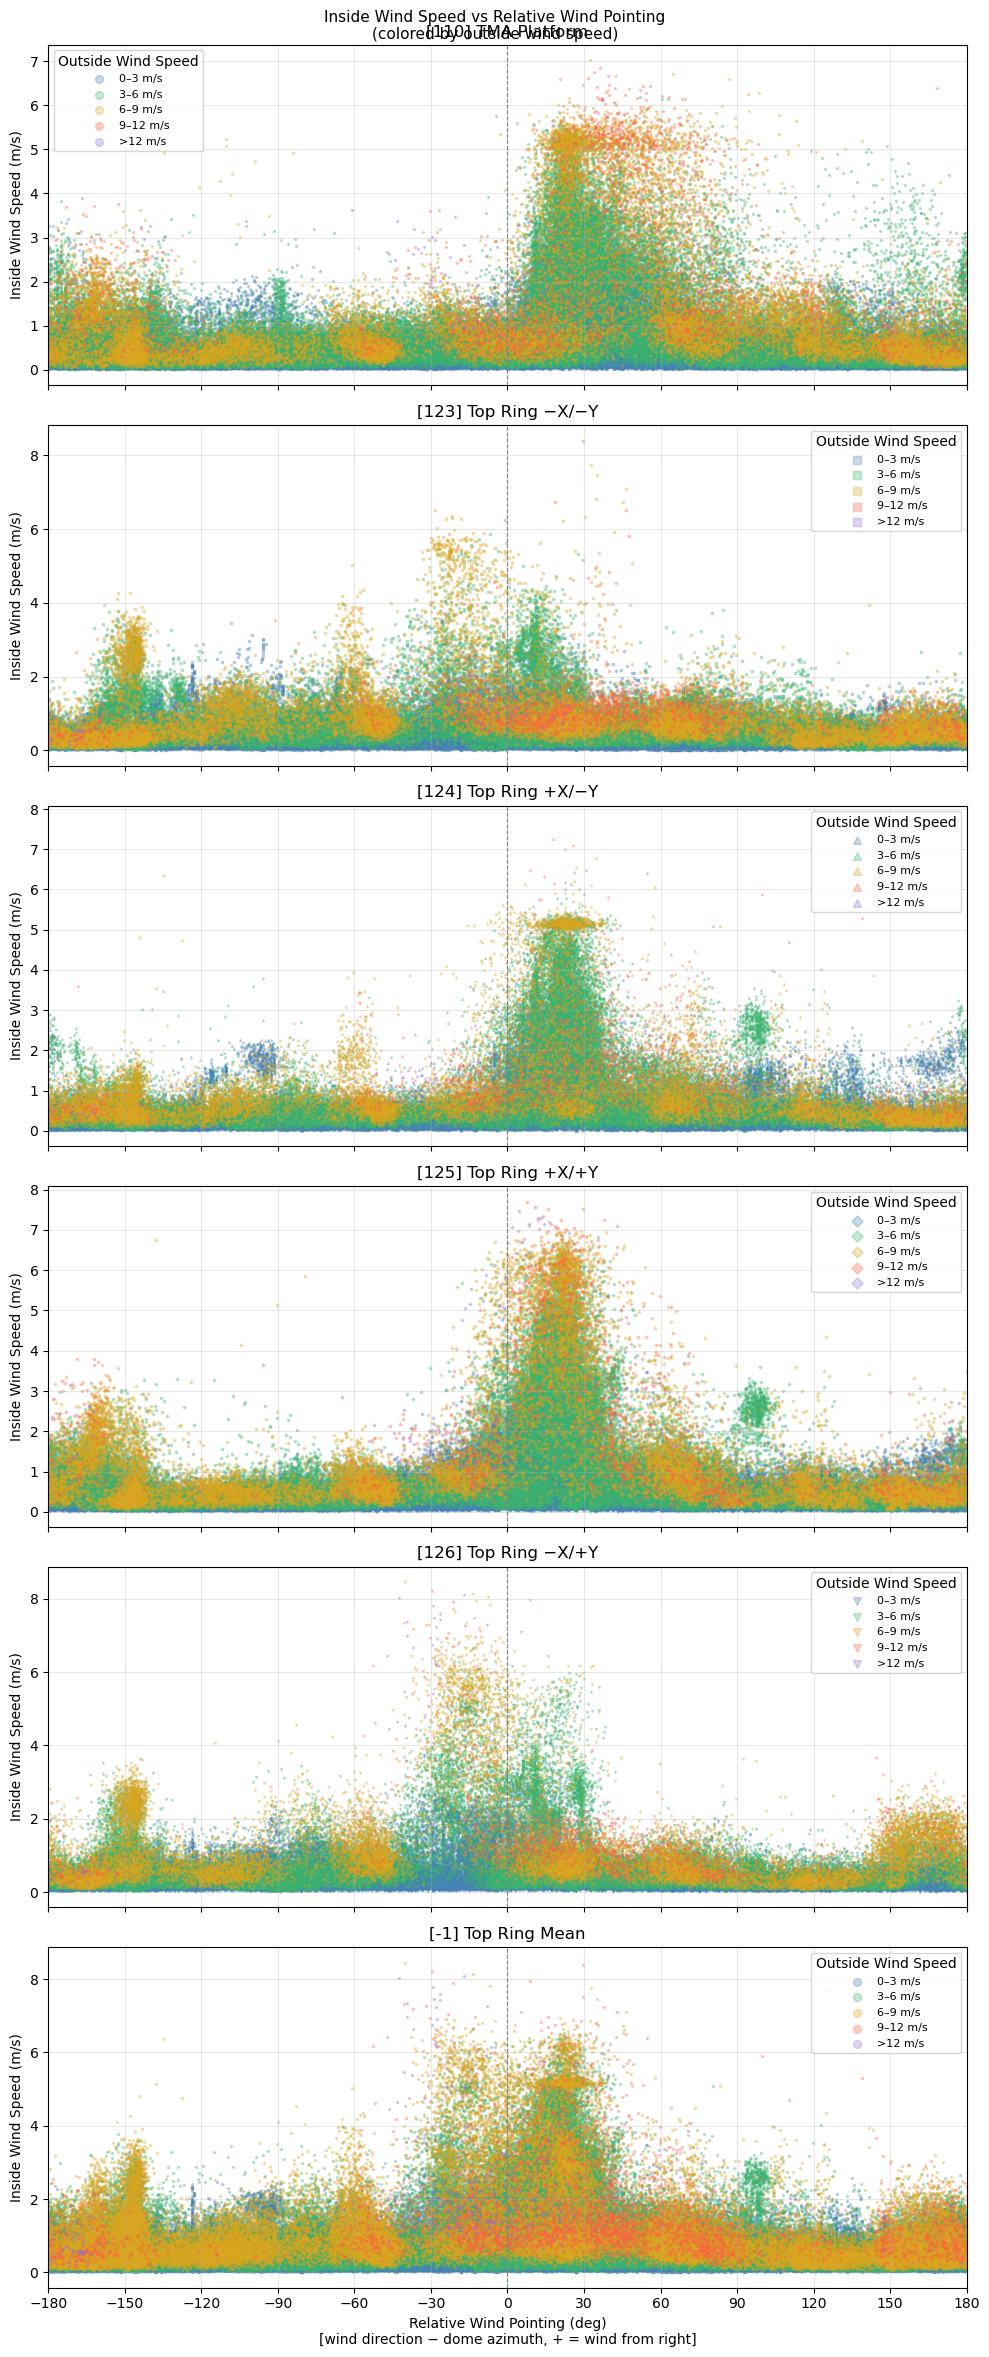

In [23]:
sensor_markers = ["o", "s", "^", "D", "v"]
n_sensors = len(sensor_list)
fig, axes = plt.subplots(n_sensors, 1, figsize=(10, 4 * n_sensors), squeeze=False, sharex=True)

for row_idx, (idx, label) in enumerate(sensor_list):
    ax = axes[row_idx, 0]
    sub_sensor = df_all[df_all["sensor_idx"] == idx]
    marker = sensor_markers[row_idx % len(sensor_markers)]

    for bin_label, bin_color in zip(wind_speed_labels, wind_speed_colors):
        sub_bin = sub_sensor[sub_sensor["speed_bin"] == bin_label].dropna(
            subset=["relative_wind", speed_field]
        )
        if sub_bin.empty:
            continue
        ax.scatter(
            sub_bin["relative_wind"], sub_bin[speed_field],
            s=2, alpha=0.3, color=bin_color, marker=marker, label=bin_label,
        )

    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel("Inside Wind Speed (m/s)")
    ax.set_title(f"[{idx}] {label}")
    ax.set_xlim(-180, 180)
    ax.set_xticks(range(-180, 181, 30))
    ax.legend(fontsize=8, markerscale=4, title="Outside Wind Speed")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Relative Wind Pointing (deg)\n[wind direction − dome azimuth, + = wind from right]")
fig.suptitle("Inside Wind Speed vs Relative Wind Pointing\n(colored by outside wind speed)", fontsize=11)
plt.tight_layout()
plt.show()

## Binned Mean Wind Speed vs Relative Wind Pointing

Bins the scatter above into 15° windows and plots mean ± 1σ per sensor.

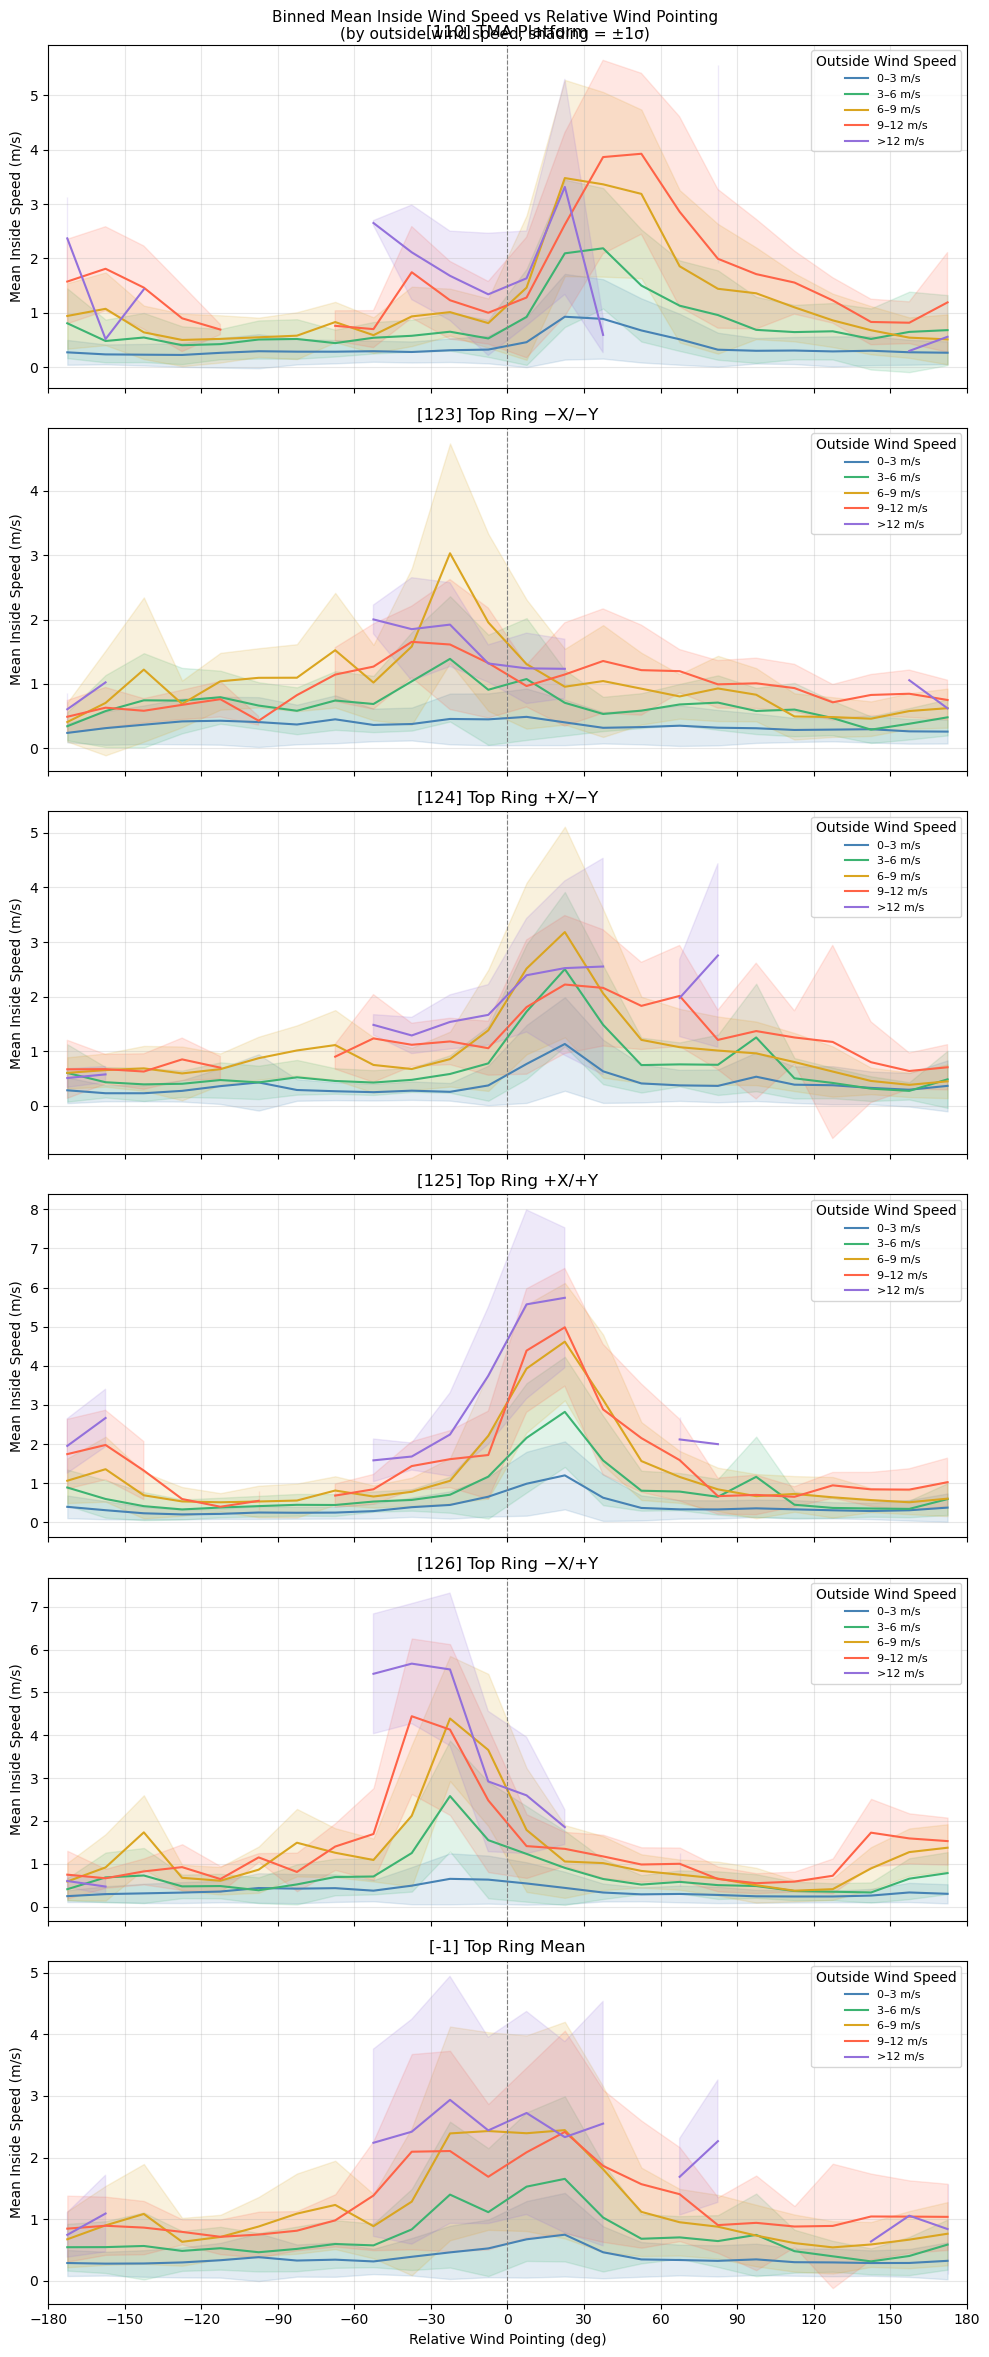

In [24]:
n_sensors = len(sensor_list)
fig, axes = plt.subplots(n_sensors, 1, figsize=(10, 4 * n_sensors), squeeze=False, sharex=True)

for row_idx, (idx, label) in enumerate(sensor_list):
    ax = axes[row_idx, 0]
    sub_sensor = df_all[df_all["sensor_idx"] == idx]

    for bin_label, bin_color in zip(wind_speed_labels, wind_speed_colors):
        sub = sub_sensor[sub_sensor["speed_bin"] == bin_label].dropna(
            subset=["relative_wind", speed_field]
        )
        if sub.empty:
            continue

        bi = np.digitize(sub["relative_wind"], bin_edges) - 1
        means, stds = [], []
        for b in range(len(bin_centers)):
            vals = sub.loc[bi == b, speed_field]
            means.append(vals.mean() if len(vals) else np.nan)
            stds.append(vals.std()   if len(vals) else np.nan)

        means = np.array(means)
        stds  = np.array(stds)
        ax.plot(bin_centers, means, lw=1.5, color=bin_color, label=bin_label)
        ax.fill_between(bin_centers, means - stds, means + stds, alpha=0.15, color=bin_color)

    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel("Mean Inside Speed (m/s)")
    ax.set_title(f"[{idx}] {label}")
    ax.set_xlim(-180, 180)
    ax.set_xticks(range(-180, 181, 30))
    ax.legend(fontsize=8, title="Outside Wind Speed")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Relative Wind Pointing (deg)")
fig.suptitle(
    "Binned Mean Inside Wind Speed vs Relative Wind Pointing\n(by outside wind speed, shading = ±1σ)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Polar Plot — Wind Speed vs Relative Pointing

Shows mean wind speed in each 15° bin as a bar in polar coordinates.
0° = dome opening faces the wind; ±180° = wind from behind the dome.

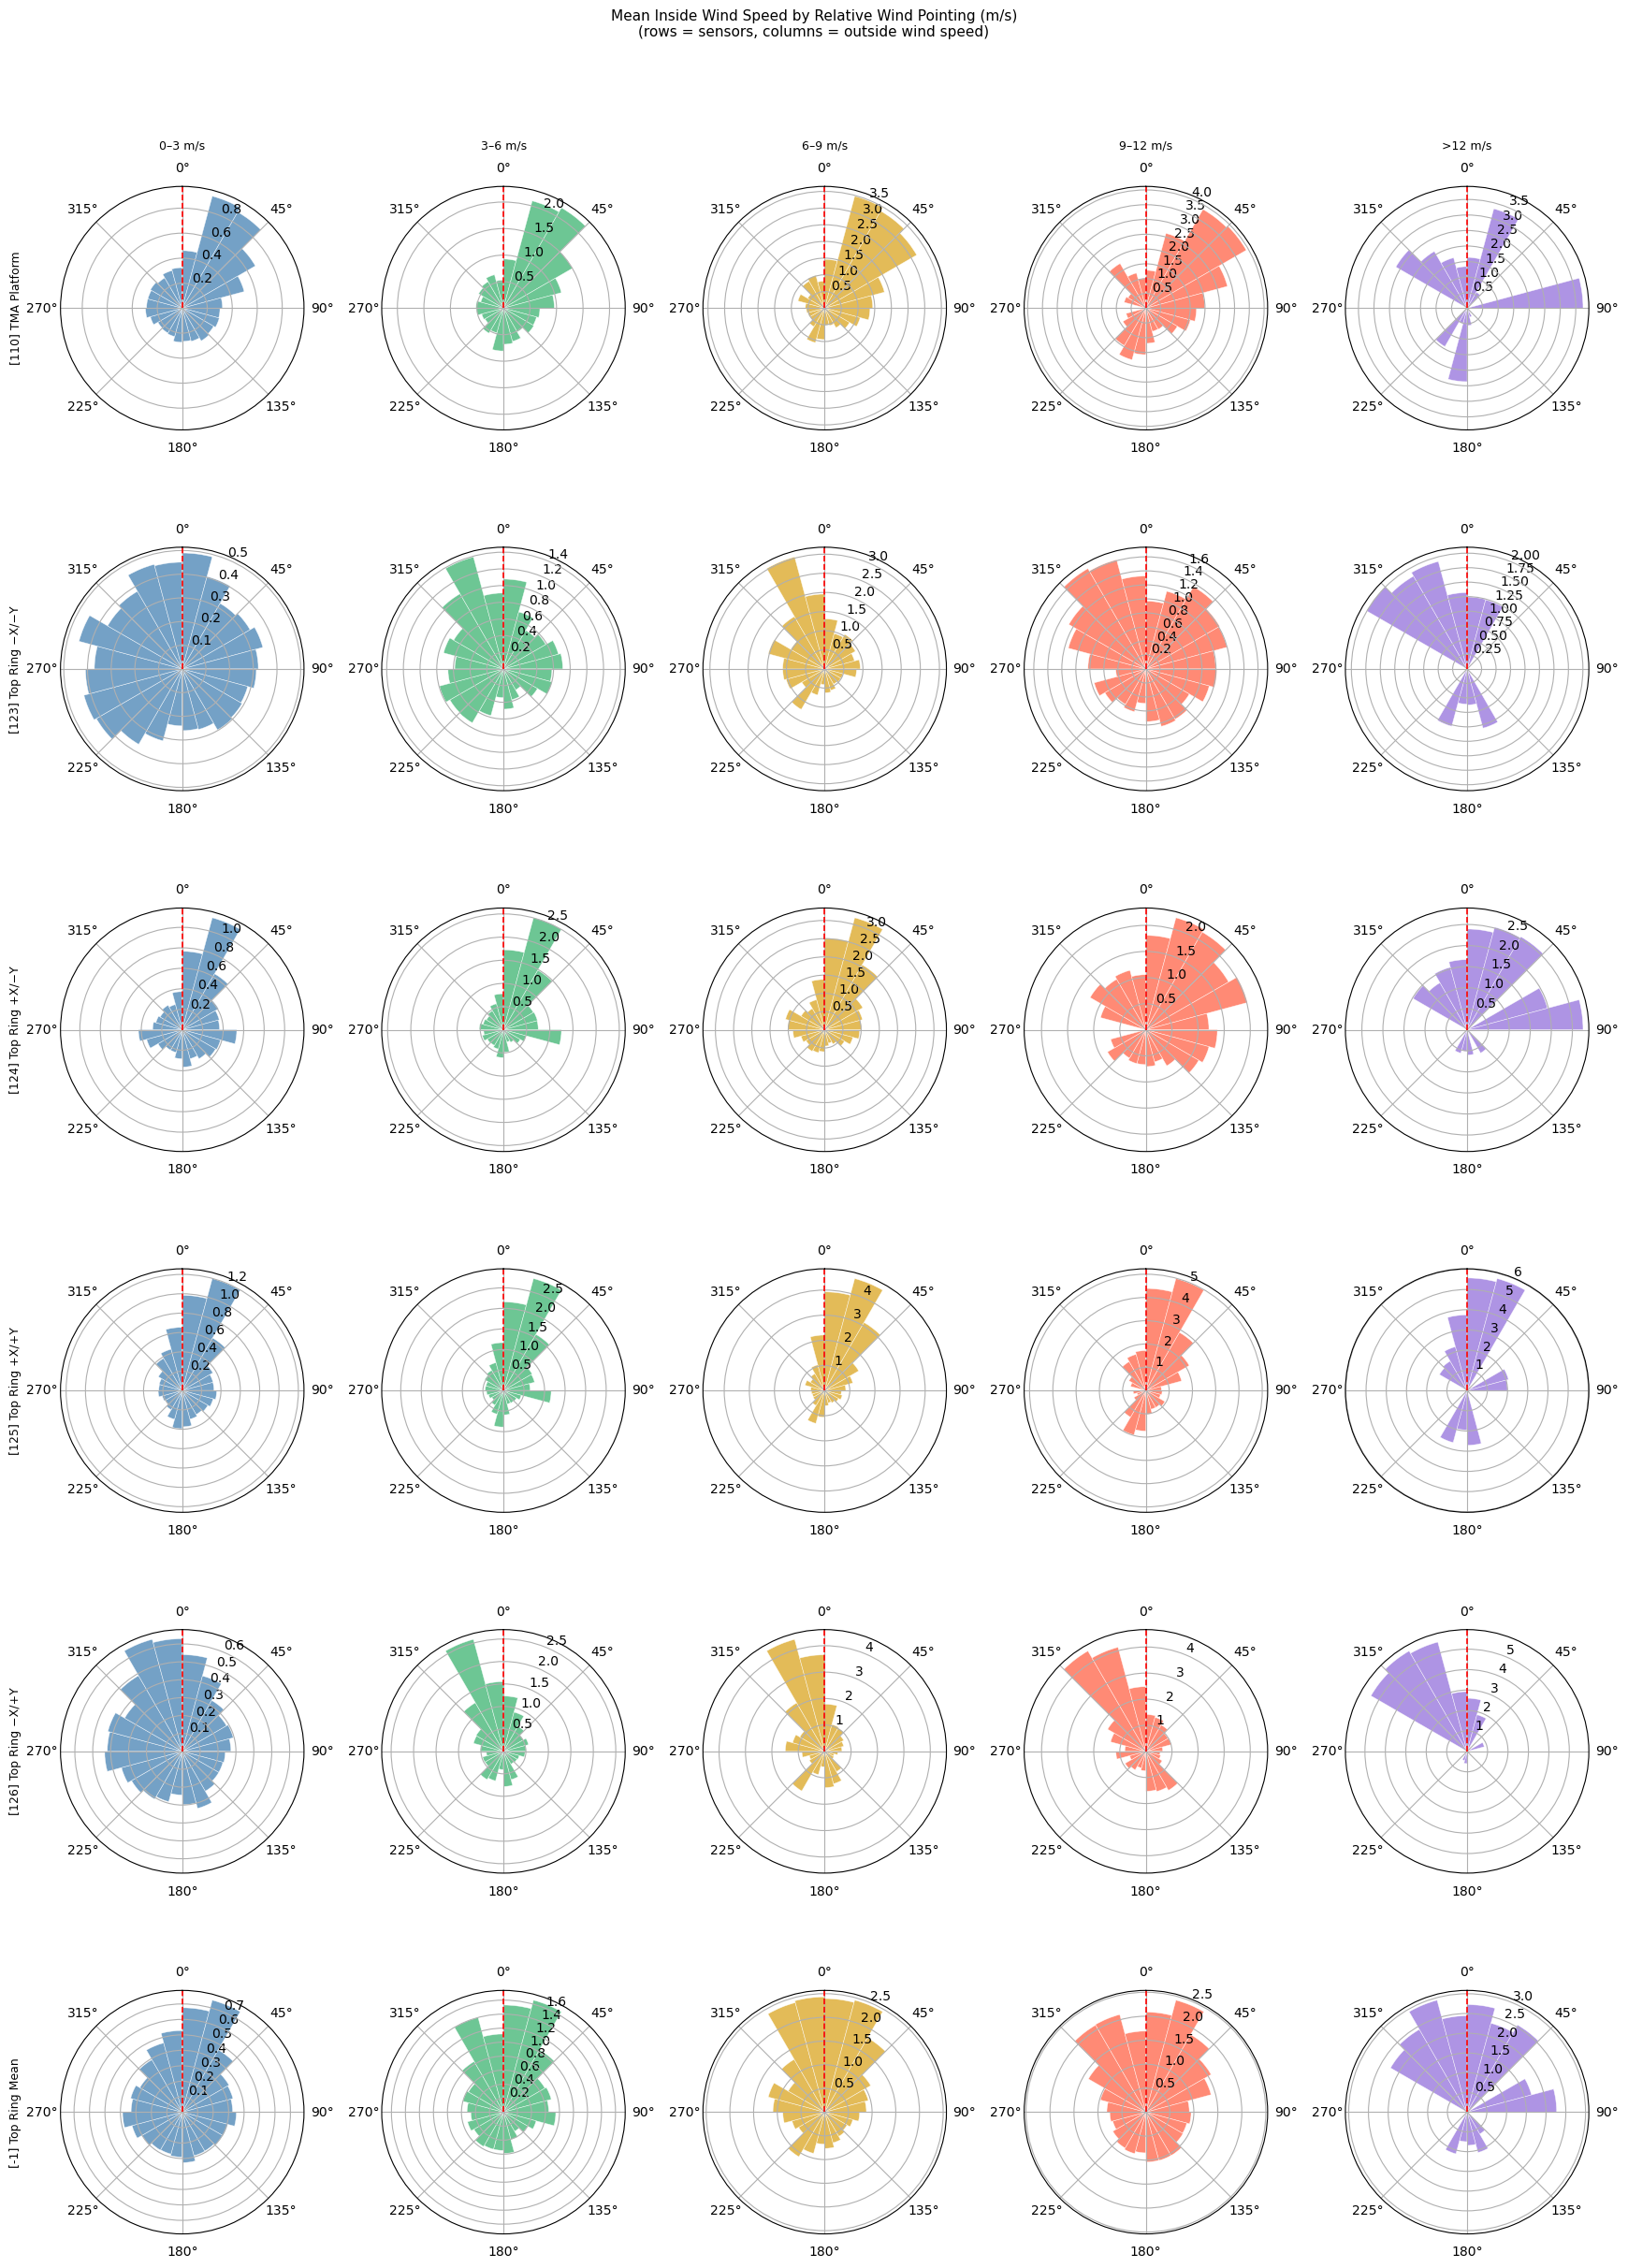

In [25]:
n_sensors = len(sensor_list)
n_bins    = len(wind_speed_labels)
fig, axes = plt.subplots(
    n_sensors, n_bins,
    figsize=(3.5 * n_bins, 4 * n_sensors),
    subplot_kw={"projection": "polar"},
    squeeze=False,
)

for row_idx, (idx, label) in enumerate(sensor_list):
    for col_idx, (bin_label, bin_color) in enumerate(zip(wind_speed_labels, wind_speed_colors)):
        ax = axes[row_idx, col_idx]
        sub = df_all[
            (df_all["sensor_idx"] == idx) & (df_all["speed_bin"] == bin_label)
        ].dropna(subset=["relative_wind", speed_field])

        if sub.empty:
            ax.set_title(f"{bin_label}\n(no data)", fontsize=9, pad=10)
            continue

        bi = np.digitize(sub["relative_wind"], bin_edges) - 1
        means = np.array([
            sub.loc[bi == b, speed_field].mean() if (bi == b).any() else 0.0
            for b in range(len(bin_centers))
        ])

        ax.bar(
            bin_centers_rad, means,
            width=bin_width_rad, bottom=0,
            color=bin_color, alpha=0.75, edgecolor="white", linewidth=0.4,
        )
        ax.axvline(0, color="red", lw=1.2, ls="--")
        ax.set_theta_zero_location("N")
        ax.set_theta_direction(-1)

        if row_idx == 0:
            ax.set_title(f"{bin_label}", fontsize=9, pad=10)
        if col_idx == 0:
            ax.set_ylabel(f"[{idx}] {label}", labelpad=30, fontsize=9)

fig.suptitle(
    "Mean Inside Wind Speed by Relative Wind Pointing (m/s)\n(rows = sensors, columns = outside wind speed)",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## Turbulence Intensity vs Relative Wind Pointing

Turbulence intensity = σ(speed) / mean(speed) within each 15° bin.

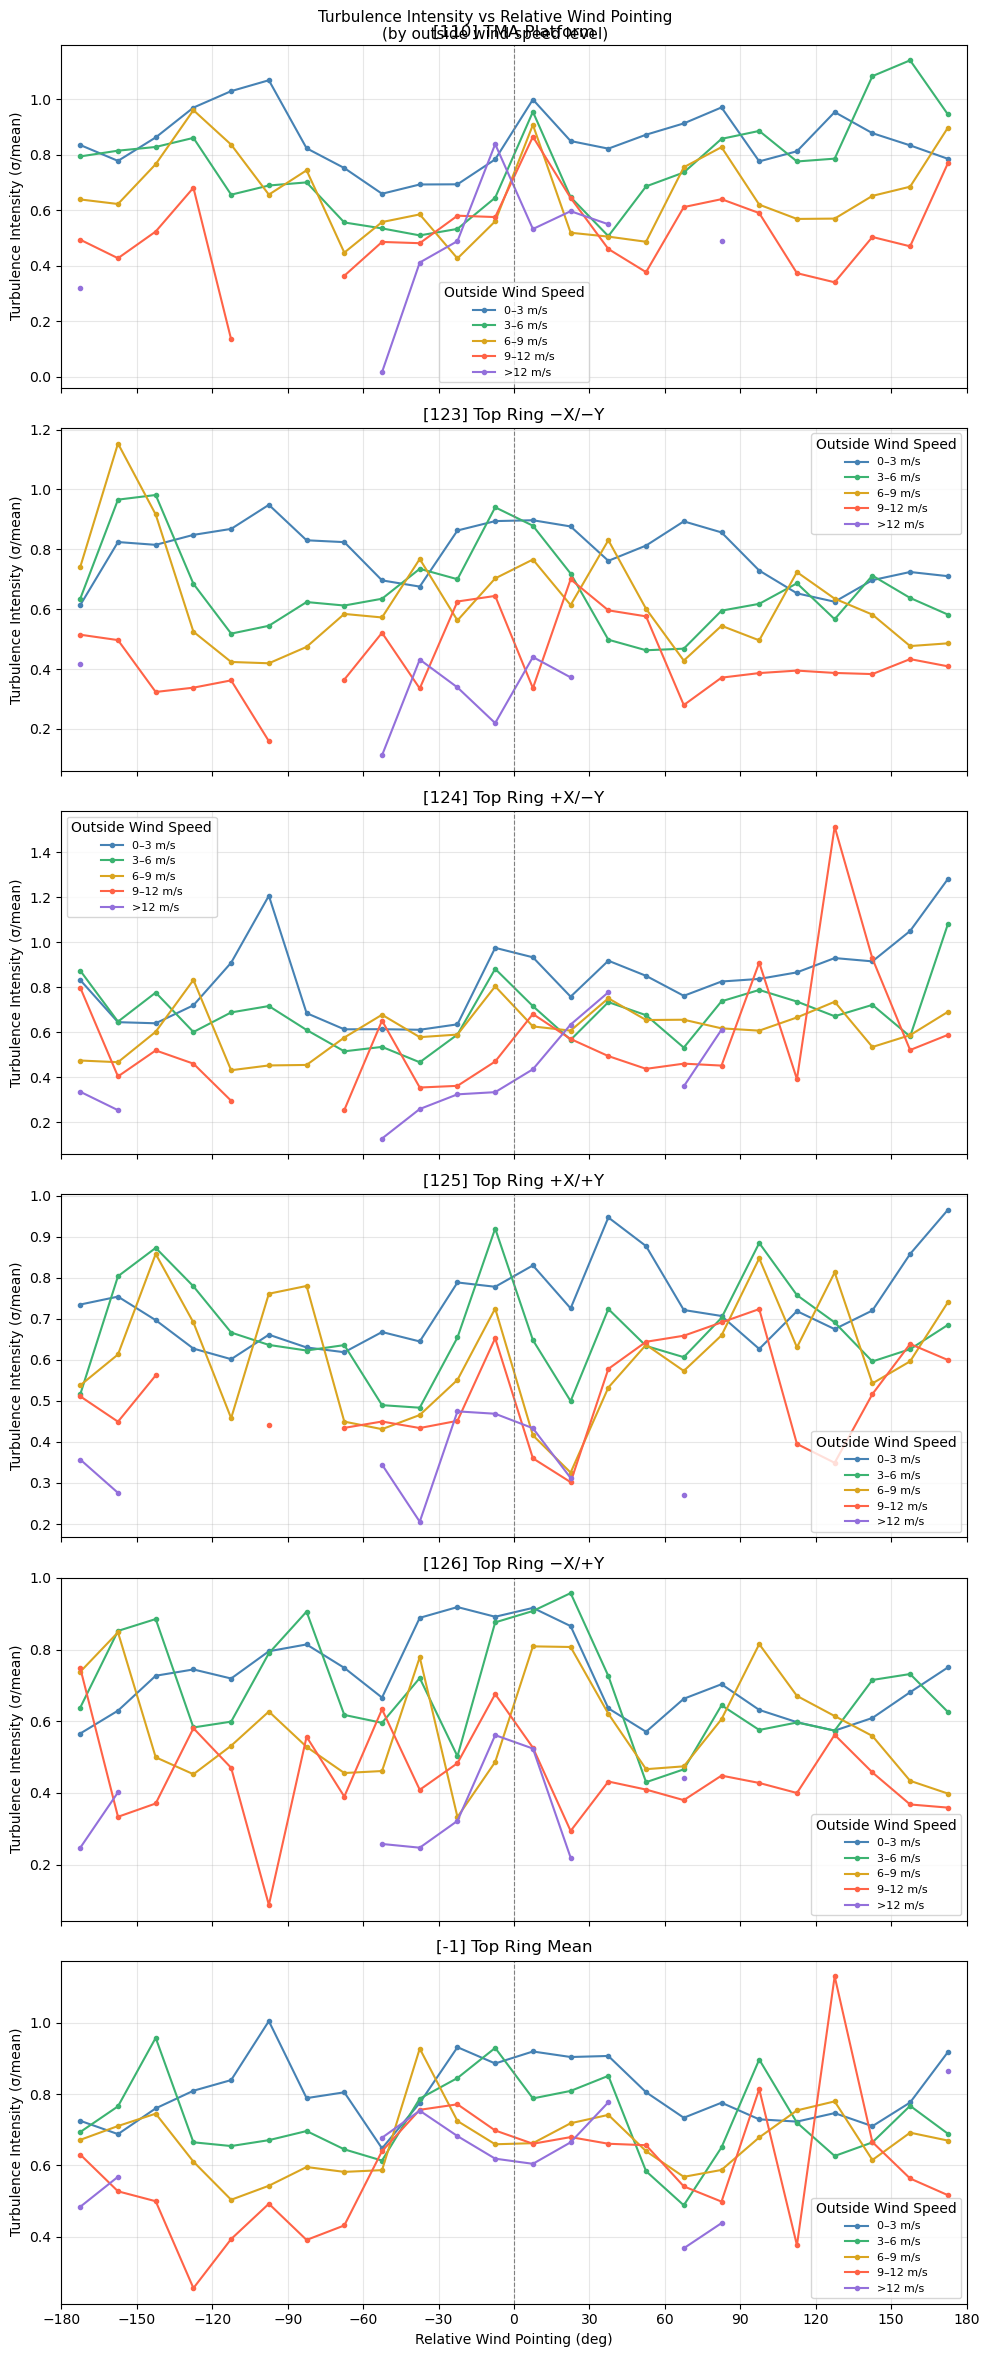

In [26]:
n_sensors = len(sensor_list)
fig, axes = plt.subplots(n_sensors, 1, figsize=(10, 4 * n_sensors), squeeze=False, sharex=True)

for row_idx, (idx, label) in enumerate(sensor_list):
    ax = axes[row_idx, 0]
    sub_sensor = df_all[df_all["sensor_idx"] == idx]

    for bin_label, bin_color in zip(wind_speed_labels, wind_speed_colors):
        sub = sub_sensor[sub_sensor["speed_bin"] == bin_label].dropna(
            subset=["relative_wind", speed_field]
        )
        if sub.empty:
            continue

        bi = np.digitize(sub["relative_wind"], bin_edges) - 1
        ti = []
        for b in range(len(bin_centers)):
            vals = sub.loc[bi == b, speed_field]
            mean_v = vals.mean()
            ti.append(vals.std() / mean_v if mean_v > 0 and len(vals) > 1 else np.nan)

        ax.plot(bin_centers, ti, lw=1.5, color=bin_color, label=bin_label, marker="o", ms=3)

    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel("Turbulence Intensity (σ/mean)")
    ax.set_title(f"[{idx}] {label}")
    ax.set_xlim(-180, 180)
    ax.set_xticks(range(-180, 181, 30))
    ax.legend(fontsize=8, title="Outside Wind Speed")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Relative Wind Pointing (deg)")
fig.suptitle(
    "Turbulence Intensity vs Relative Wind Pointing\n(by outside wind speed level)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## Sonic Temperature StdDev vs Relative Wind Pointing

`sonicTemperatureStdDev` measures variability in the speed-of-sound-derived air temperature —
a proxy for thermal turbulence intensity independent of wind speed.

/lscratch/stalder/tmp/ipykernel_1075117/2012473957.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


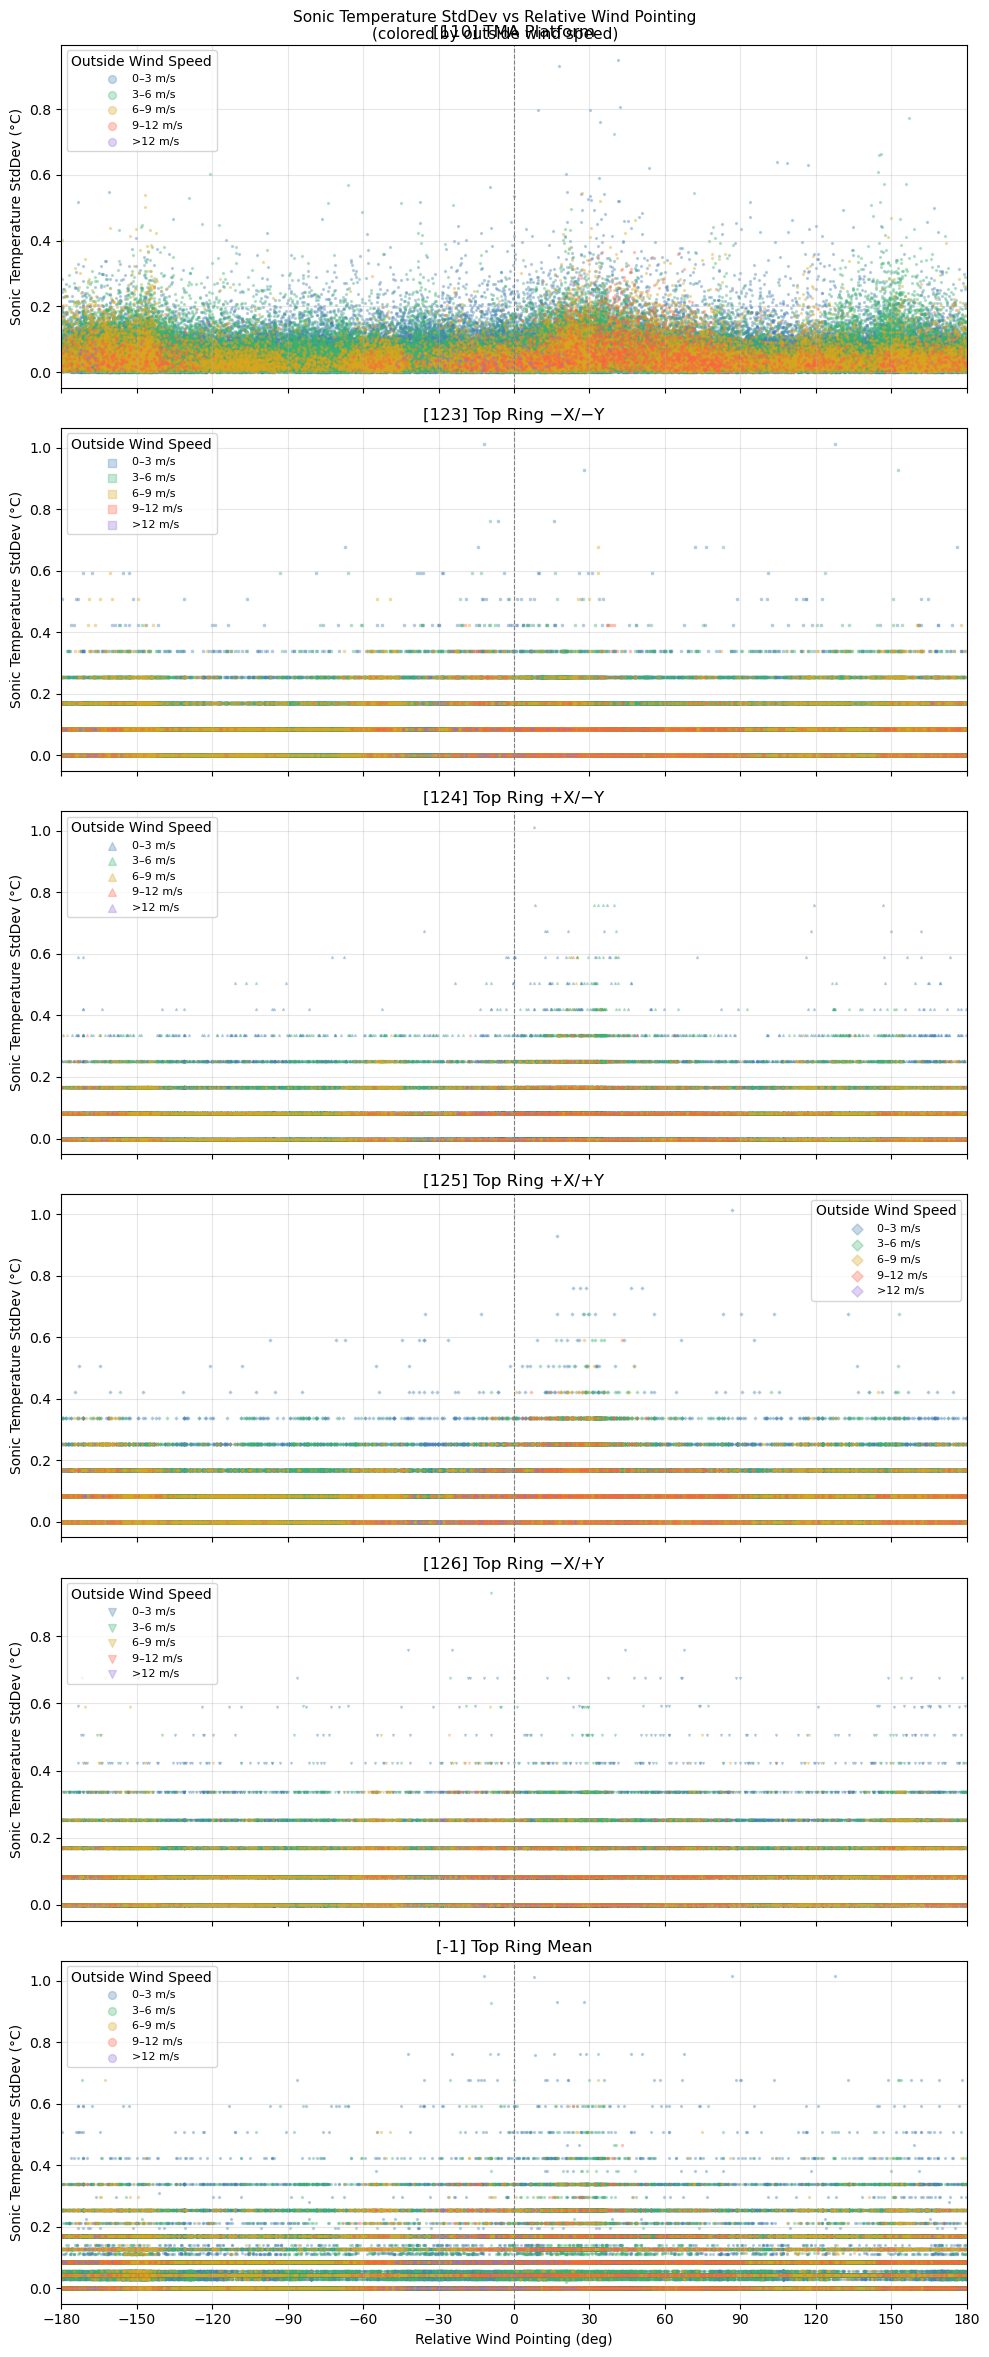

In [27]:
sensor_markers = ["o", "s", "^", "D", "v"]
n_sensors = len(sensor_list)
fig, axes = plt.subplots(n_sensors, 1, figsize=(10, 4 * n_sensors), squeeze=False, sharex=True)

for row_idx, (idx, label) in enumerate(sensor_list):
    ax = axes[row_idx, 0]
    sub_sensor = df_all[df_all["sensor_idx"] == idx]
    marker = sensor_markers[row_idx % len(sensor_markers)]

    for bin_label, bin_color in zip(wind_speed_labels, wind_speed_colors):
        sub_bin = sub_sensor[sub_sensor["speed_bin"] == bin_label].dropna(
            subset=["relative_wind", sonic_field]
        )
        if sub_bin.empty:
            continue
        ax.scatter(
            sub_bin["relative_wind"], sub_bin[sonic_field],
            s=2, alpha=0.3, color=bin_color, marker=marker, label=bin_label,
        )

    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel("Sonic Temperature StdDev (°C)")
    ax.set_title(f"[{idx}] {label}")
    ax.set_xlim(-180, 180)
    ax.set_xticks(range(-180, 181, 30))
    ax.legend(fontsize=8, markerscale=4, title="Outside Wind Speed")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Relative Wind Pointing (deg)")
fig.suptitle("Sonic Temperature StdDev vs Relative Wind Pointing\n(colored by outside wind speed)", fontsize=11)
plt.tight_layout()
plt.show()

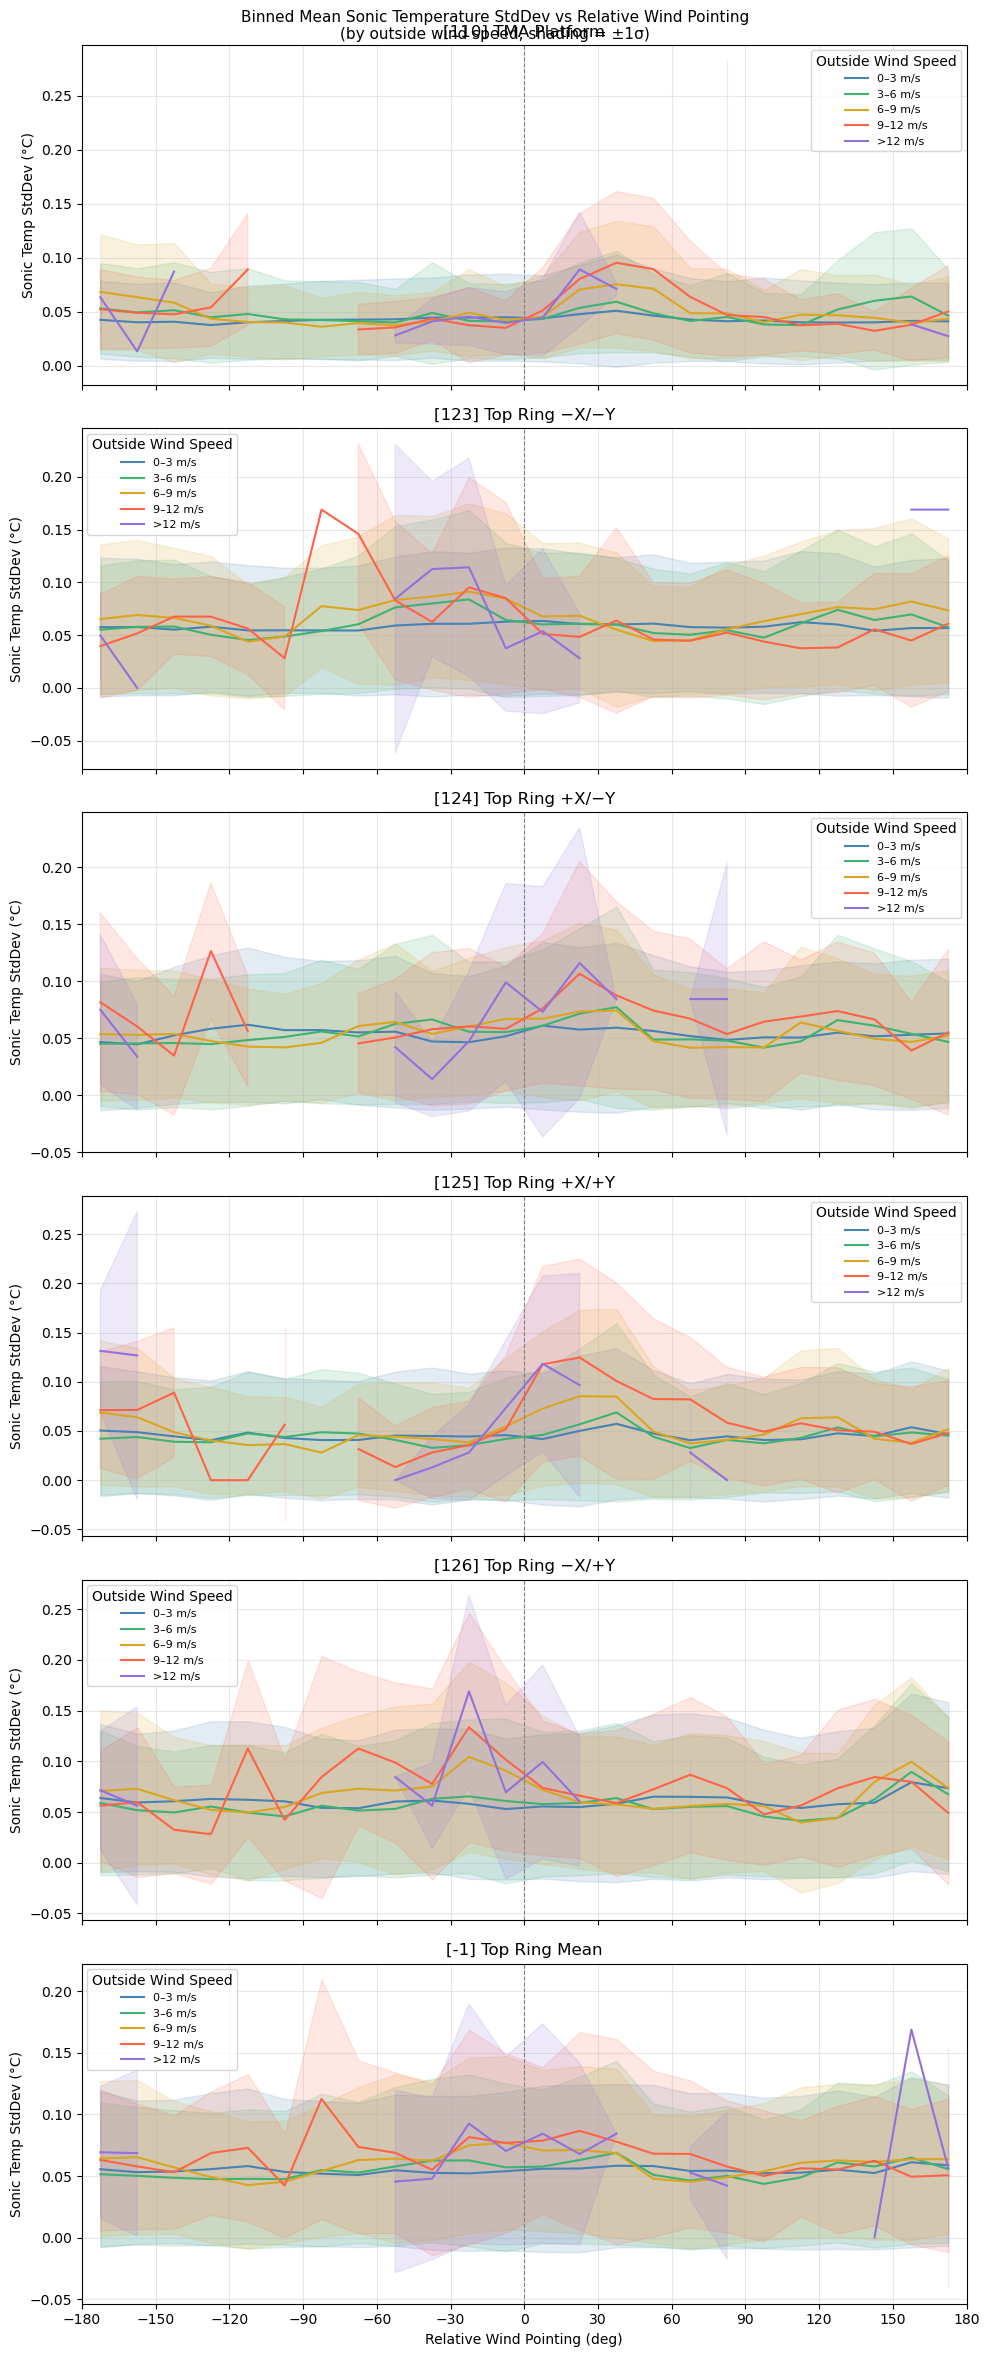

In [28]:
n_sensors = len(sensor_list)
fig, axes = plt.subplots(n_sensors, 1, figsize=(10, 4 * n_sensors), squeeze=False, sharex=True)

for row_idx, (idx, label) in enumerate(sensor_list):
    ax = axes[row_idx, 0]
    sub_sensor = df_all[df_all["sensor_idx"] == idx]

    for bin_label, bin_color in zip(wind_speed_labels, wind_speed_colors):
        sub = sub_sensor[sub_sensor["speed_bin"] == bin_label].dropna(
            subset=["relative_wind", sonic_field]
        )
        if sub.empty:
            continue

        bi = np.digitize(sub["relative_wind"], bin_edges) - 1
        means, stds = [], []
        for b in range(len(bin_centers)):
            vals = sub.loc[bi == b, sonic_field]
            means.append(vals.mean() if len(vals) else np.nan)
            stds.append(vals.std()   if len(vals) else np.nan)

        means = np.array(means)
        stds  = np.array(stds)
        ax.plot(bin_centers, means, lw=1.5, color=bin_color, label=bin_label)
        ax.fill_between(bin_centers, means - stds, means + stds, alpha=0.15, color=bin_color)

    ax.axvline(0, color="gray", lw=0.8, ls="--")
    ax.set_ylabel("Sonic Temp StdDev (°C)")
    ax.set_title(f"[{idx}] {label}")
    ax.set_xlim(-180, 180)
    ax.set_xticks(range(-180, 181, 30))
    ax.legend(fontsize=8, title="Outside Wind Speed")
    ax.grid(True, alpha=0.3)

axes[-1, 0].set_xlabel("Relative Wind Pointing (deg)")
fig.suptitle(
    "Binned Mean Sonic Temperature StdDev vs Relative Wind Pointing\n(by outside wind speed, shading = ±1σ)",
    fontsize=11,
)
plt.tight_layout()
plt.show()